## Day 1

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
import os
os.chdir(r"C:\Users\PREM\OneDrive\Desktop\Bluestock_MF_Capstone")
print(os.getcwd())

C:\Users\PREM\OneDrive\Desktop\Bluestock_MF_Capstone


In [3]:

RAW = Path("data/raw")

fund_master    = pd.read_csv(RAW / "01_fund_master.csv")
nav_history    = pd.read_csv(RAW / "02_nav_history.csv")
aum_fund_house = pd.read_csv(RAW / "03_aum_by_fund_house.csv")
sip_inflows    = pd.read_csv(RAW / "04_monthly_sip_inflows.csv")
cat_inflows    = pd.read_csv(RAW / "05_category_inflows.csv")
folio_count    = pd.read_csv(RAW / "06_industry_folio_count.csv")
scheme_perf    = pd.read_csv(RAW / "07_scheme_performance.csv")
transactions   = pd.read_csv(RAW / "08_investor_transactions.csv")
portfolio      = pd.read_csv(RAW / "09_portfolio_holdings.csv")
benchmarks     = pd.read_csv(RAW / "10_benchmark_indices.csv")


print(f"fund_master    → {fund_master.shape}")
print(f"nav_history    → {nav_history.shape}")
print(f"aum_fund_house → {aum_fund_house.shape}")
print(f"sip_inflows    → {sip_inflows.shape}")
print(f"cat_inflows    → {cat_inflows.shape}")
print(f"folio_count    → {folio_count.shape}")
print(f"scheme_perf    → {scheme_perf.shape}")
print(f"transactions   → {transactions.shape}")
print(f"portfolio      → {portfolio.shape}")
print(f"benchmarks     → {benchmarks.shape}")

fund_master    → (40, 15)
nav_history    → (46000, 3)
aum_fund_house → (90, 5)
sip_inflows    → (48, 6)
cat_inflows    → (144, 3)
folio_count    → (21, 6)
scheme_perf    → (40, 19)
transactions   → (32778, 13)
portfolio      → (322, 8)
benchmarks     → (8050, 3)


In [4]:
print("=== FUND MASTER ===")
print(f"Fund Houses : {fund_master['fund_house'].nunique()}")
print(f"Categories  : {fund_master['category'].unique()}")
print(f"Risk Grades : {fund_master['risk_category'].unique()}")
fund_master.head()

=== FUND MASTER ===
Fund Houses : 10
Categories  : ['Equity' 'Debt']
Risk Grades : ['Moderate' 'Very High' 'Low' 'High' 'Moderately High']


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


## Day2

In [5]:
print("Cleaning NAV History...")

nav_history["date"] = pd.to_datetime(nav_history["date"])

nav_history = nav_history.sort_values(["amfi_code", "date"])

before = len(nav_history)
nav_history = nav_history.drop_duplicates(subset=["amfi_code", "date"])
print(f"  Duplicates removed : {before - len(nav_history)}")

nav_history = nav_history[nav_history["nav"] > 0]

nav_history["daily_return_pct"] = (
    nav_history
    .groupby("amfi_code")["nav"]
    .pct_change()
    .mul(100)
    .round(4)
)

print(f"  Final shape : {nav_history.shape}")
print(f"  Date range  : {nav_history['date'].min()} to {nav_history['date'].max()}")
nav_history.head(3)

Cleaning NAV History...
  Duplicates removed : 0
  Final shape : (46000, 4)
  Date range  : 2022-01-03 00:00:00 to 2026-05-29 00:00:00


,amfi_code,date,nav,daily_return_pct
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-1.0306
5752,100016,2022-01-05,521.7239,1.2865


In [6]:
print("Cleaning Transactions...")

transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

transactions["transaction_type"] = (
    transactions["transaction_type"]
    .str.strip()
    .str.title()
)

before = len(transactions)
transactions = transactions[transactions["amount_inr"] > 0]
print(f"  Invalid amounts removed : {before - len(transactions)}")
print(f"  Transaction types       : {transactions['transaction_type'].unique()}")
print(f"  KYC status values       : {transactions['kyc_status'].unique()}")
print(f"  Final shape             : {transactions.shape}")
transactions.head(3)

Cleaning Transactions...
  Invalid amounts removed : 0
  Transaction types       : ['Sip' 'Redemption' 'Lumpsum']
  KYC status values       : ['Verified' 'Pending']
  Final shape             : (32778, 13)


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified


In [7]:
print("Cleaning Scheme Performance...")

number_cols = [
    "return_1yr_pct", "return_3yr_pct", "return_5yr_pct",
    "sharpe_ratio", "alpha", "beta",
    "max_drawdown_pct", "expense_ratio_pct"
]

for col in number_cols:
    scheme_perf[col] = pd.to_numeric(scheme_perf[col], errors="coerce")

print(f"  Missing values:\n{scheme_perf.isnull().sum()[scheme_perf.isnull().sum() > 0]}")
print(f"  Final shape : {scheme_perf.shape}")
scheme_perf.head(3)

Cleaning Scheme Performance...
  Missing values:
Series([], dtype: int64)
  Final shape : (40, 19)


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High


## Day3

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_palette("Blues_d")

print("Chart libraries ready!")

Chart libraries ready!


In [9]:
import os

# Create reports folder if it doesn't exist
os.makedirs("reports", exist_ok=True)

print("Reports folder ready!")

Reports folder ready!


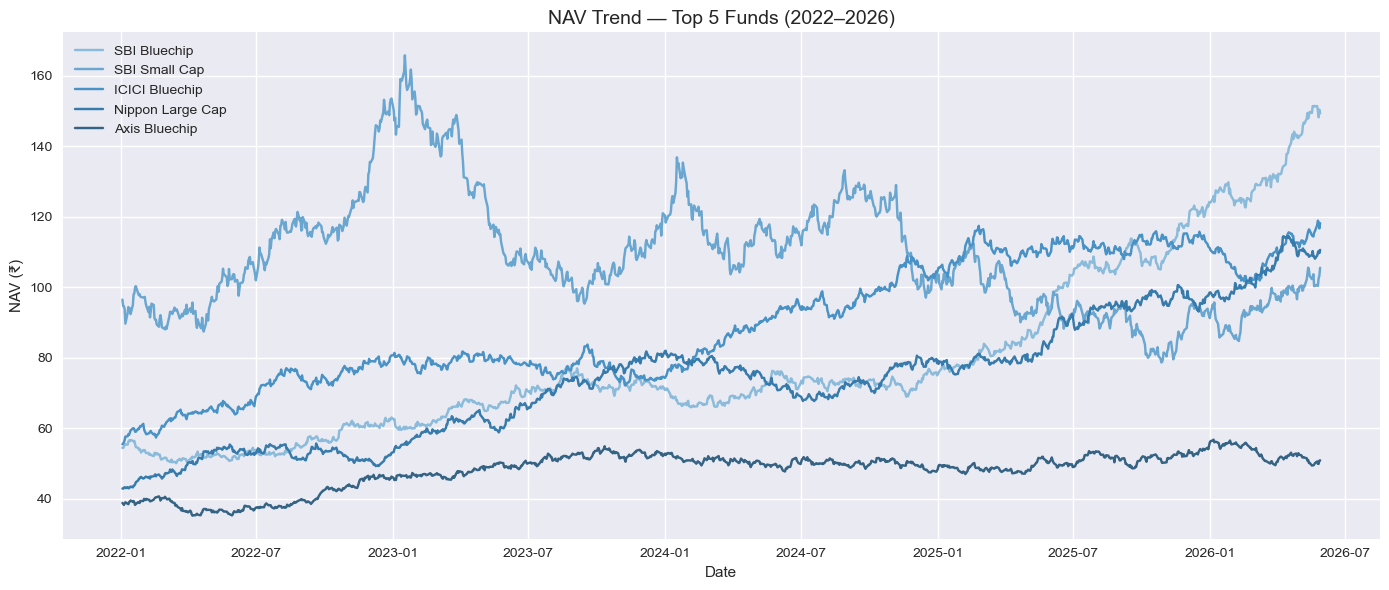

Chart saved → reports/nav_trend.png


In [10]:
top5_codes = [119551, 119599, 120503, 118632, 119092]
top5_names = {
    119551: "SBI Bluechip",
    119599: "SBI Small Cap",
    120503: "ICICI Bluechip",
    118632: "Nippon Large Cap",
    119092: "Axis Bluechip"
}

plt.figure(figsize=(14, 6))

for code in top5_codes:
    fund_nav = nav_history[nav_history["amfi_code"] == code]
    plt.plot(fund_nav["date"], fund_nav["nav"], label=top5_names[code])

plt.title("NAV Trend — Top 5 Funds (2022–2026)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("NAV (₹)")
plt.legend()
plt.tight_layout()
plt.savefig("reports/nav_trend.png")
plt.show()
print("Chart saved → reports/nav_trend.png")

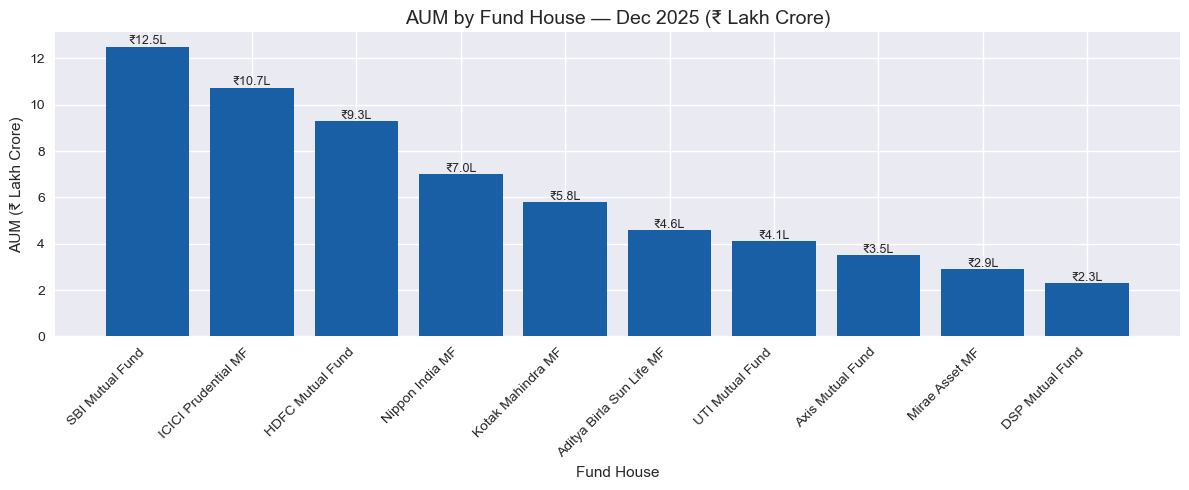

Chart saved → reports/aum_by_fund_house.png


In [11]:
# Get latest AUM for each fund house
latest_date = aum_fund_house["date"].max()
latest_aum  = aum_fund_house[aum_fund_house["date"] == latest_date]
latest_aum  = latest_aum.sort_values("aum_lakh_crore", ascending=False)

plt.figure(figsize=(12, 5))
bars = plt.bar(latest_aum["fund_house"], latest_aum["aum_lakh_crore"], color="#185fa5")
plt.title("AUM by Fund House — Dec 2025 (₹ Lakh Crore)", fontsize=14)
plt.xlabel("Fund House")
plt.ylabel("AUM (₹ Lakh Crore)")
plt.xticks(rotation=45, ha="right")

# Add value labels on top of each bar
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f"₹{bar.get_height():.1f}L",
             ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("reports/aum_by_fund_house.png")
plt.show()
print("Chart saved → reports/aum_by_fund_house.png")

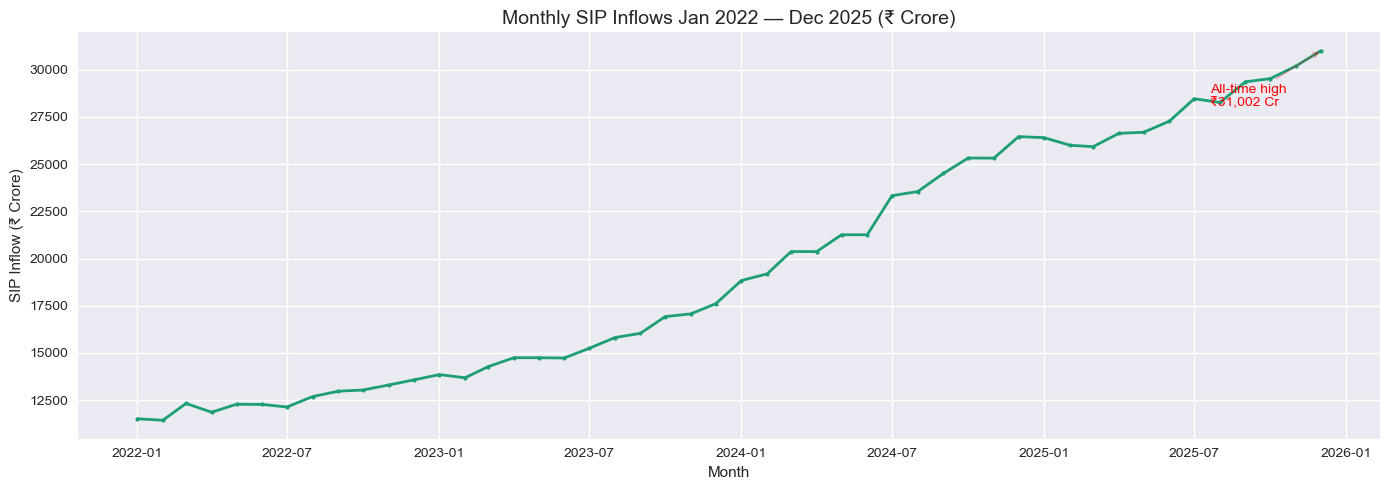

Chart saved → reports/sip_trend.png


In [12]:
sip_inflows["month_dt"] = pd.to_datetime(sip_inflows["month"])

plt.figure(figsize=(14, 5))
plt.plot(sip_inflows["month_dt"], sip_inflows["sip_inflow_crore"],
         color="#1d9e75", linewidth=2, marker="o", markersize=3)

# Mark the all-time high
max_idx = sip_inflows["sip_inflow_crore"].idxmax()
plt.annotate("All-time high\n₹31,002 Cr",
             xy=(sip_inflows.loc[max_idx, "month_dt"],
                 sip_inflows.loc[max_idx, "sip_inflow_crore"]),
             xytext=(-80, -40), textcoords="offset points",
             arrowprops=dict(arrowstyle="->", color="red"),
             color="red", fontsize=10)

plt.title("Monthly SIP Inflows Jan 2022 — Dec 2025 (₹ Crore)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("SIP Inflow (₹ Crore)")
plt.tight_layout()
plt.savefig("reports/sip_trend.png")
plt.show()
print("Chart saved → reports/sip_trend.png")

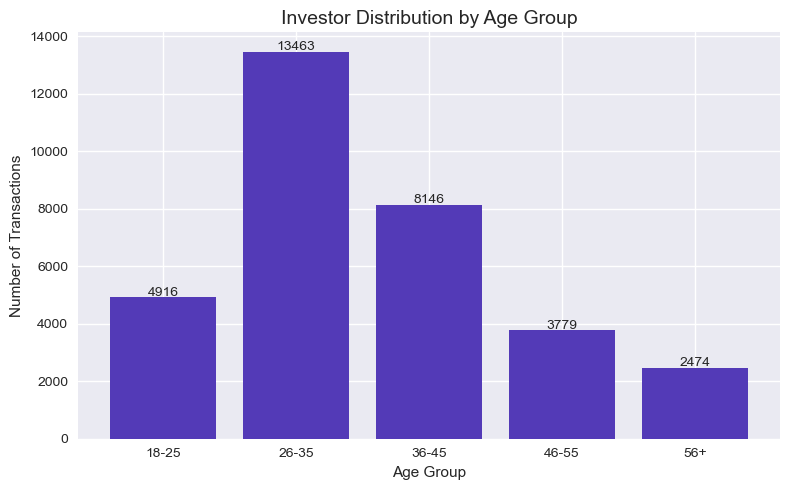

Chart saved → reports/age_distribution.png


In [13]:
age_counts = transactions["age_group"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
bars = plt.bar(age_counts.index, age_counts.values, color="#533ab7")
plt.title("Investor Distribution by Age Group", fontsize=14)
plt.xlabel("Age Group")
plt.ylabel("Number of Transactions")

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50,
             str(bar.get_height()),
             ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("reports/age_distribution.png")
plt.show()
print("Chart saved → reports/age_distribution.png")

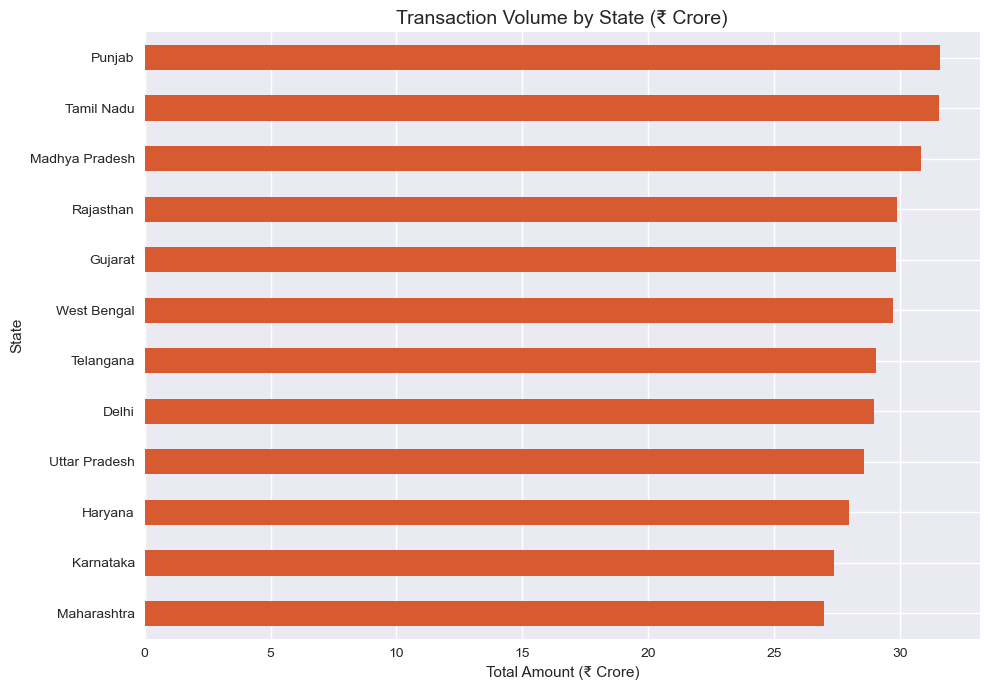

Chart saved → reports/state_volume.png


In [14]:
state_volume = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .div(1e7)          # convert to crore
    .round(2)
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))
state_volume.plot(kind="barh", color="#d85a30")
plt.title("Transaction Volume by State (₹ Crore)", fontsize=14)
plt.xlabel("Total Amount (₹ Crore)")
plt.ylabel("State")
plt.tight_layout()
plt.savefig("reports/state_volume.png")
plt.show()
print("Chart saved → reports/state_volume.png")

In [15]:
print("=" * 55)
print("KEY EDA FINDINGS")
print("=" * 55)
print(f"1. Largest fund house     : {latest_aum.iloc[0]['fund_house']} (₹{latest_aum.iloc[0]['aum_lakh_crore']}L Cr)")
print(f"2. SIP inflow growth      : ₹11,517 Cr → ₹31,002 Cr (+169%)")
print(f"3. Total transactions     : {len(transactions):,}")
print(f"4. Most active age group  : {age_counts.idxmax()}")
print(f"5. Top state by volume    : {state_volume.idxmax()}")
print(f"6. NAV date range         : {nav_history['date'].min().date()} to {nav_history['date'].max().date()}")
print("=" * 55)

KEY EDA FINDINGS
1. Largest fund house     : SBI Mutual Fund (₹12.5L Cr)
2. SIP inflow growth      : ₹11,517 Cr → ₹31,002 Cr (+169%)
3. Total transactions     : 32,778
4. Most active age group  : 26-35
5. Top state by volume    : Punjab
6. NAV date range         : 2022-01-03 to 2026-05-29


## Day 4

In [16]:
print("Computing daily returns for all 40 funds...")

# Compute daily return % for each fund
nav_history["daily_return"] = (
    nav_history
    .groupby("amfi_code")["nav"]
    .pct_change()
)

print(f"Daily returns computed!")
print(nav_history[["amfi_code", "date", "nav", "daily_return"]].head(5))

Computing daily returns for all 40 funds...
Daily returns computed!
      amfi_code       date       nav  daily_return
5750     100016 2022-01-03  520.4608           NaN
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210


In [18]:
RF_ANNUAL = 0.065
RF_DAILY  = RF_ANNUAL / 252

sharpe_results = []

for code, grp in nav_history.groupby("amfi_code"):
    rets = grp["daily_return"].dropna()

    if len(rets) < 50:
        continue

    excess_return = rets - RF_DAILY
    sharpe = (excess_return.mean() / rets.std()) * (252 ** 0.5)

    sharpe_results.append({
        "amfi_code"   : code,
        "sharpe_ratio": round(sharpe, 4)
    })

sharpe_df = pd.DataFrame(sharpe_results).sort_values("sharpe_ratio", ascending=False)
print("✅ Sharpe Ratio computed!")
sharpe_df.head(10)

✅ Sharpe Ratio computed!


,amfi_code,sharpe_ratio
34,148567,1.4483
30,120843,1.3067
36,148569,1.2349
19,119551,1.2083
25,120505,1.1801
38,149323,1.1321
2,100033,1.0937
9,118632,1.0817
3,101206,1.0272
24,120504,1.0265


In [19]:
print("Computing CAGR...")

cagr_results = []

for code, grp in nav_history.groupby("amfi_code"):
    grp = grp.sort_values("date")

    start_nav = grp["nav"].iloc[0]
    end_nav   = grp["nav"].iloc[-1]
    n_years   = len(grp) / 252      # 252 trading days in a year

    cagr = (end_nav / start_nav) ** (1 / n_years) - 1

    cagr_results.append({
        "amfi_code": code,
        "start_nav": round(start_nav, 2),
        "end_nav"  : round(end_nav, 2),
        "n_years"  : round(n_years, 2),
        "cagr_pct" : round(cagr * 100, 2)
    })

cagr_df = pd.DataFrame(cagr_results).sort_values("cagr_pct", ascending=False)
print("CAGR computed!")
cagr_df.head(10)

Computing CAGR...
CAGR computed!


,amfi_code,start_nav,end_nav,n_years,cagr_pct
25,120505,135.87,473.76,4.56,31.48
21,119598,89.87,309.20,4.56,31.10
39,149324,81.68,279.75,4.56,30.97
36,148569,28.86,97.74,4.56,30.64
34,148567,70.25,230.27,4.56,29.71
30,120843,49.91,163.24,4.56,29.65
2,100033,107.38,342.01,4.56,28.90
38,149323,78.46,245.37,4.56,28.38
16,119094,68.30,203.86,4.56,27.08
19,119551,54.39,149.32,4.56,24.77


In [20]:
drawdown_results = []

for code, grp in nav_history.groupby("amfi_code"):
    grp = grp.sort_values("date")
    nav = grp["nav"]

    # Running maximum NAV up to each day
    running_max = nav.cummax()

    # Drawdown = how much below the peak
    drawdown = (nav - running_max) / running_max
    max_dd   = drawdown.min()

    drawdown_results.append({
        "amfi_code"      : code,
        "max_drawdown_pct": round(max_dd * 100, 2)
    })

dd_df = pd.DataFrame(drawdown_results).sort_values("max_drawdown_pct")
print("Max Drawdown computed!")
dd_df.head(10)

Max Drawdown computed!


,amfi_code,max_drawdown_pct
22,119599,-52.57
17,119095,-51.68
4,101207,-35.45
39,149324,-31.17
21,119598,-28.71
7,102886,-28.00
0,100016,-24.73
29,120842,-24.00
11,118634,-23.34
15,119093,-21.75


In [21]:
from scipy import stats

nifty = benchmarks[benchmarks["index_name"] == "NIFTY50"].copy()
nifty["date"]       = pd.to_datetime(nifty["date"])
nifty["bench_ret"]  = nifty["close_value"].pct_change()
nifty = nifty[["date", "bench_ret"]].dropna()

alpha_beta_results = []

for code, grp in nav_history.groupby("amfi_code"):
    grp = grp.sort_values("date")[["date", "daily_return"]].dropna()

    merged = grp.merge(nifty, on="date", how="inner")

    if len(merged) < 50:
        continue

    slope, intercept, r, p, se = stats.linregress(
        merged["bench_ret"],
        merged["daily_return"]
    )

    alpha = intercept * 252   
    beta  = slope

    alpha_beta_results.append({
        "amfi_code": code,
        "alpha"    : round(alpha, 4),
        "beta"     : round(beta, 4)
    })

ab_df = pd.DataFrame(alpha_beta_results)
print("Alpha & Beta computed!")
ab_df.head(10)

Alpha & Beta computed!


,amfi_code,alpha,beta
0,100016,0.0362,-0.0259
1,100025,0.0432,-0.0162
2,100033,0.2723,-0.0112
3,101206,0.2139,0.0338
4,101207,0.1082,-0.0599
5,101208,0.0608,0.0013
6,102885,0.1699,-0.0019
7,102886,0.0289,-0.0615
8,102887,0.1618,0.0401
9,118632,0.2173,0.0364


In [23]:
scorecard = cagr_df[["amfi_code", "cagr_pct"]].merge(sharpe_df, on="amfi_code")
scorecard = scorecard.merge(dd_df, on="amfi_code")
scorecard = scorecard.merge(ab_df, on="amfi_code")
scorecard = scorecard.merge(
    fund_master[["amfi_code", "scheme_name", "fund_house", "category", "expense_ratio_pct"]],
    on="amfi_code"
)

n = len(scorecard)
scorecard["rank_cagr"]    = scorecard["cagr_pct"].rank()
scorecard["rank_sharpe"]  = scorecard["sharpe_ratio"].rank()
scorecard["rank_alpha"]   = scorecard["alpha"].rank()
scorecard["rank_exp"]     = scorecard["expense_ratio_pct"].rank(ascending=False)
scorecard["rank_dd"]      = scorecard["max_drawdown_pct"].rank(ascending=False)

scorecard["score"] = (
    0.30 * scorecard["rank_cagr"]   / n * 100 +
    0.25 * scorecard["rank_sharpe"] / n * 100 +
    0.20 * scorecard["rank_alpha"]  / n * 100 +
    0.15 * scorecard["rank_exp"]    / n * 100 +
    0.10 * scorecard["rank_dd"]     / n * 100
).round(2)

scorecard = scorecard.sort_values("score", ascending=False)

scorecard.to_csv("data/processed/fund_scorecard.csv", index=False)

print("Fund Scorecard built!")
print(f"\nTop 10 Funds:")
scorecard[["scheme_name", "cagr_pct", "sharpe_ratio", "alpha", "score"]].head(10)

Fund Scorecard built!

Top 10 Funds:


,scheme_name,cagr_pct,sharpe_ratio,alpha,score
0,ICICI Pru Midcap Fund - Regular - Growth,31.48,1.1801,0.2930,87.50
1,SBI Small Cap Fund - Regular Plan - Growth,31.10,0.9453,0.3011,82.62
2,DSP Small Cap Fund - Regular - Growth,30.97,0.9498,0.2982,80.19
5,Kotak Flexicap Fund - Regular - Growth,29.65,1.3067,0.2728,79.00
6,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,28.90,1.0937,0.2723,78.25
4,Mirae Asset Large Cap Fund - Regular - Growth,29.71,1.4483,0.2712,77.75
3,Mirae Asset Tax Saver Fund - Regular - Growth,30.64,1.2349,0.2835,76.94
8,Axis Midcap Fund - Regular - Growth,27.08,0.9982,0.2600,74.75
9,SBI Bluechip Fund - Regular Plan - Growth,24.77,1.2083,0.2322,70.06
10,Nippon India Large Cap Fund - Regular - Growth,23.09,1.0817,0.2173,70.06


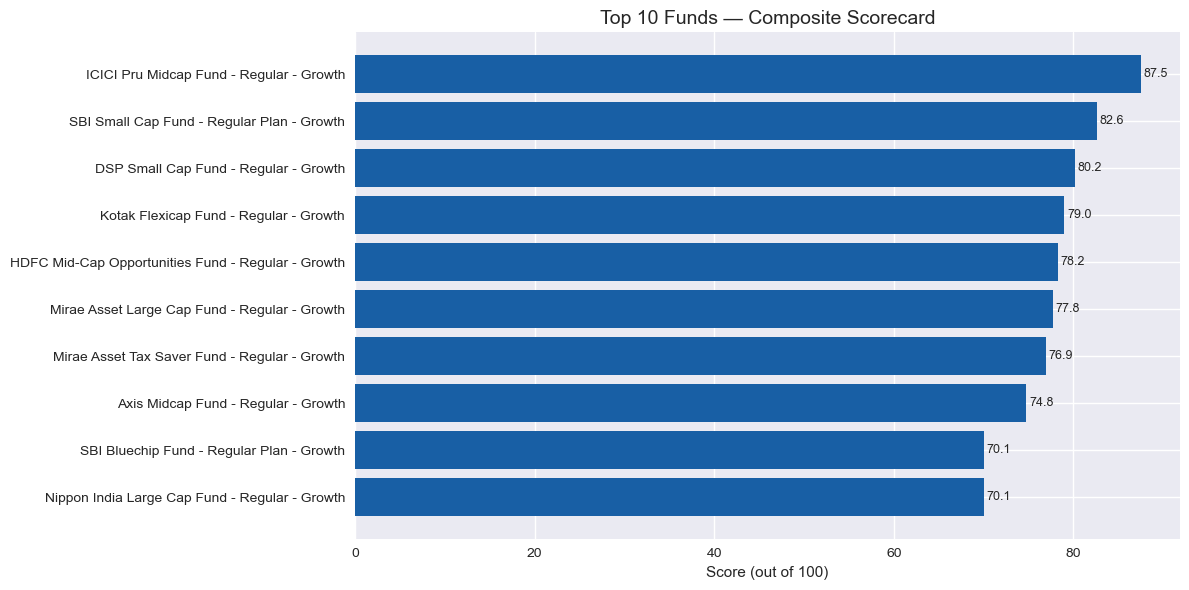

Chart saved → reports/fund_scorecard.png


In [24]:
top10 = scorecard.head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(top10["scheme_name"], top10["score"], color="#185fa5")
plt.title("Top 10 Funds — Composite Scorecard", fontsize=14)
plt.xlabel("Score (out of 100)")
plt.gca().invert_yaxis()

for bar in bars:
    plt.text(bar.get_width() + 0.3,
             bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():.1f}",
             va="center", fontsize=9)

plt.tight_layout()
plt.savefig("reports/fund_scorecard.png")
plt.show()
print("Chart saved → reports/fund_scorecard.png")